# Generation Evaluation Analysis

This notebook analyzes the verdict generation evaluation JSON. It focuses on: 

- Top $n$ most frequent retrieved law articles
- Top $n$ most frequent applied law articles from the model prediction
- Top $n$ most frequent law articles in the ground truth
- Most accurate and least accurate cases by `Phat_tu` RMSE

The article counts are computed at the *Dieu* level by taking the prefix before the first hyphen, so `174-4-a` is counted as article `174`.

In [5]:
from collections import Counter
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

#RESULT_PATH = Path("output/bench/one_call_full.json")
#RESULT_PATH = Path("output/reasoning_act_eval/results.json")
#RESULT_PATH = Path("act_full.json")
RESULT_PATH = Path("output/reasoning_act_eval/results_2024.json")
#RESULT_PATH_2 = Path("output/generation_eval/combine__first250.json")
#RESULT_PATH_3 = Path("output/generation_eval/verdict_generation_eval_reasoning50.json")

TOP_N = 30

print(f"Loading: {RESULT_PATH.resolve()}")

Loading: /home/hieujayce/Downloads/complete_repo/output/reasoning_act_eval/results_2024.json


In [6]:
with RESULT_PATH.open(encoding="utf-8") as fh:
    result = json.load(fh)

per_doc = result.get("per_doc", [])
summary = result.get("summary", {})

def article_from_signature(signature):
    text = str(signature or "").strip()
    if not text:
        return None
    article = text.split("-", 1)[0].strip()
    return article or None

def normalize_signature_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [part.strip() for part in value.split(",") if part.strip()]
    if isinstance(value, list):
        out = []
        for item in value:
            if isinstance(item, dict):
                signature = item.get("signature") or item.get("dieu") or item.get("article")
                if signature:
                    out.append(str(signature).strip())
            else:
                text = str(item).strip()
                if text:
                    out.append(text)
        return out
    return [str(value).strip()] if str(value).strip() else []

def article_set_from_values(values):
    return sorted({article_from_signature(signature) for signature in normalize_signature_list(values) if article_from_signature(signature)})

def collect_articles_from_defendants(doc, side):
    articles = set()
    defendants = doc.get("defendants") or []
    if not isinstance(defendants, list):
        defendants = []
    for item in defendants:
        if not isinstance(item, dict):
            continue
        payload = item.get(side) or {}
        if not isinstance(payload, dict):
            continue
        articles.update(article_set_from_values(payload.get("Applied_Law_Clauses", [])))
    return sorted(articles)

rows = []
for doc in per_doc:
    if doc.get("status") != "processed":
        continue

    similar_case_context = doc.get("similar_case_context") or {}
    retrieved_articles = article_set_from_values(similar_case_context.get("similar_case_law_clause_set", []))
    predicted_articles = collect_articles_from_defendants(doc, "prediction")
    ground_truth_articles = collect_articles_from_defendants(doc, "ground_truth")

    rows.append({
        "doc_id": doc.get("doc_id", ""),
        "source_file": doc.get("source_file", ""),
        "rmse_months": float(doc.get("doc_metrics", {}).get("phat_tu_rmse_months", 0.0)),
        "n_defendants_scored": int(doc.get("doc_metrics", {}).get("n_defendants_scored", 0)),
        "retrieved_articles": retrieved_articles,
        "predicted_articles": predicted_articles,
        "ground_truth_articles": ground_truth_articles,
    })

df = pd.DataFrame(rows)

print(f"Processed documents: {len(df)}")
display(df.head())

print("Summary metrics from JSON:")
display(pd.DataFrame([summary.get("metrics", {})]))

Processed documents: 94


,doc_id,source_file,rmse_months,n_defendants_scored,retrieved_articles,predicted_articles,ground_truth_articles
0,01-02-2024-Khanh_Hoa-2ta1430918t1cvn,01-02-2024-Khanh_Hoa-2ta1430918t1cvn.json,12.000000,1,[],"[173, 51]","[173, 51]"
1,01-08-2024-Bac_Giang-2ta1610530t1cvn,01-08-2024-Bac_Giang-2ta1610530t1cvn.json,6.000000,1,[],"[227, 51]","[227, 51, 65]"
2,02-08-2024-Ho_Chi_Minh-2ta1628292t1cvn,02-08-2024-Ho_Chi_Minh-2ta1628292t1cvn.json,120.000000,1,[],"[251, 51, 52]","[251, 38, 51]"
3,03-01-2024-Lai_Chau-2ta1409450t1cvn,03-01-2024-Lai_Chau-2ta1409450t1cvn.json,0.000000,2,[],"[201, 51]","[17, 201, 35, 47, 51, 58]"
4,03-05-2024-Thai_Binh-2ta1510909t1cvn,03-05-2024-Thai_Binh-2ta1510909t1cvn.json,40.024992,6,[],"[134, 51]","[101, 102, 123, 134, 15, 17, 38, 50, 51, 57, 58, 65, 90, 91]"


Summary metrics from JSON:


,law_clause_set_precision_macro,law_clause_set_recall_macro,law_clause_set_f1_macro,phat_tu_rmse_months_macro
0,0.765333,0.516209,0.596574,30.281321


Top retrieved law articles


""


No data available for Top 30 Retrieved Law Articles
Top applied law articles from model predictions


,article,case_count,share_of_cases
0,51,93,0.9894
1,52,29,0.3085
2,54,19,0.2021
3,251,17,0.1809
4,174,10,0.1064
5,134,8,0.0851
6,250,7,0.0745
7,227,5,0.0532
8,123,5,0.0532
9,249,5,0.0532


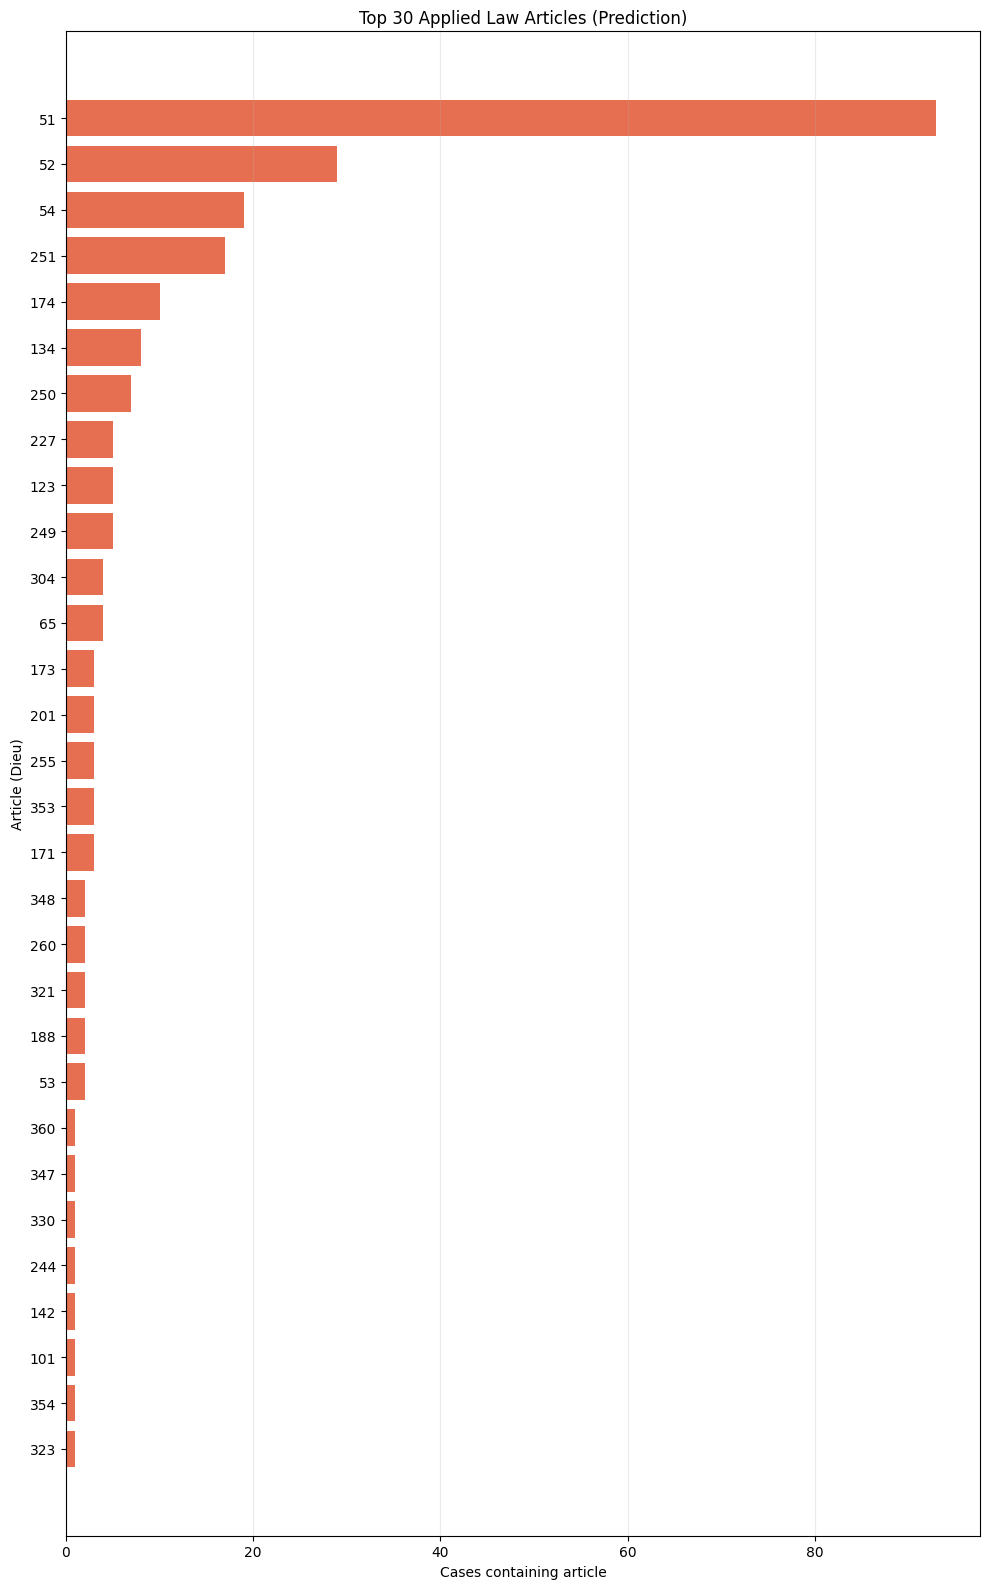

Top ground-truth law articles


,article,case_count,share_of_cases
0,51,93,0.9894
1,38,53,0.5638
2,52,26,0.2766
3,58,23,0.2447
4,251,21,0.2234
5,54,21,0.2234
6,17,20,0.2128
7,65,14,0.1489
8,123,14,0.1489
9,57,12,0.1277


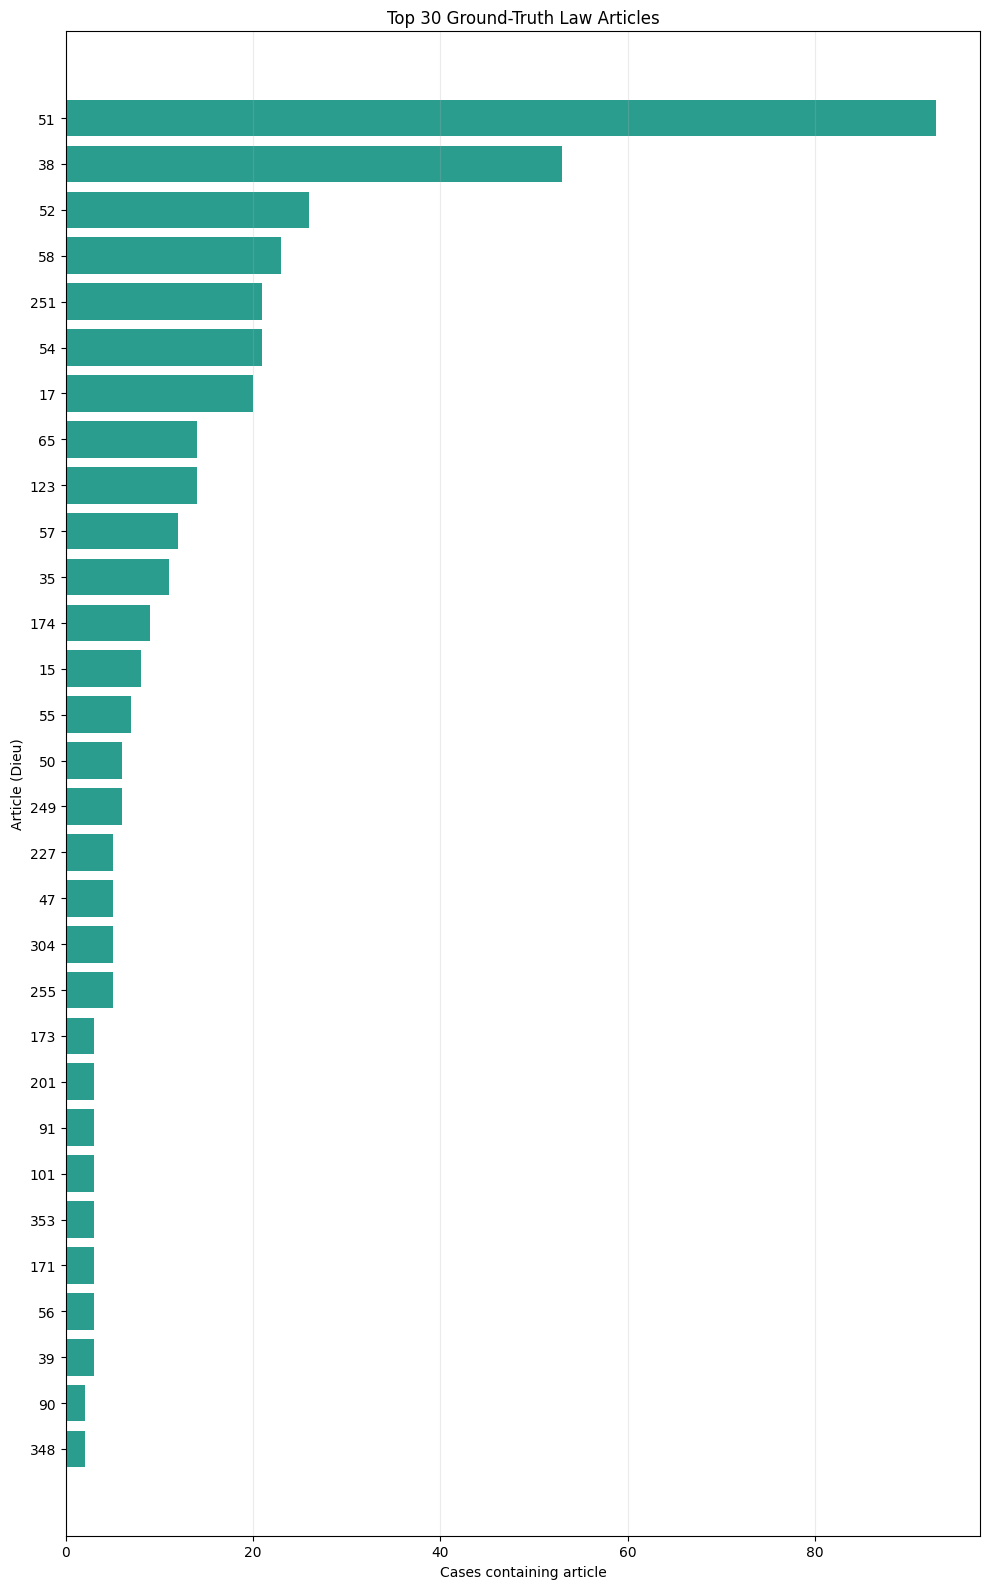

In [7]:
def count_articles(series):
    counter = Counter()
    for articles in series:
        counter.update(set(articles))
    return counter

def top_articles_table(counter, total_docs, n=10):
    rows = []
    for article, count in counter.most_common(n):
        rows.append({
            "article": article,
            "case_count": count,
            "share_of_cases": round(count / total_docs, 4) if total_docs else 0.0,
        })
    return pd.DataFrame(rows)

def plot_top_articles(counter, title, n=10, color="#2a9d8f"):
    top_items = counter.most_common(n)
    if not top_items:
        print(f"No data available for {title}")
        return

    articles = [item[0] for item in top_items][::-1]
    counts = [item[1] for item in top_items][::-1]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(top_items) + 1)))
    ax.barh(articles, counts, color=color)
    ax.set_title(title)
    ax.set_xlabel("Cases containing article")
    ax.set_ylabel("Article (Dieu)")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

total_docs = len(df)
retrieved_counter = count_articles(df["retrieved_articles"])
predicted_counter = count_articles(df["predicted_articles"])
ground_truth_counter = count_articles(df["ground_truth_articles"])

print("Top retrieved law articles")
display(top_articles_table(retrieved_counter, total_docs, TOP_N))
plot_top_articles(retrieved_counter, f"Top {TOP_N} Retrieved Law Articles", TOP_N, color="#457b9d")

print("Top applied law articles from model predictions")
display(top_articles_table(predicted_counter, total_docs, TOP_N))
plot_top_articles(predicted_counter, f"Top {TOP_N} Applied Law Articles (Prediction)", TOP_N, color="#e76f51")

print("Top ground-truth law articles")
display(top_articles_table(ground_truth_counter, total_docs, TOP_N))
plot_top_articles(ground_truth_counter, f"Top {TOP_N} Ground-Truth Law Articles", TOP_N, color="#2a9d8f")

Most accurate cases by Phat_tu RMSE (lower is better): top 30


,doc_id,source_file,rmse_months,n_defendants_scored
0,03-01-2024-Lai_Chau-2ta1409450t1cvn,03-01-2024-Lai_Chau-2ta1409450t1cvn.json,0.000000,2
1,03-07-2024-Hai_Duong-2ta1545419t1cvn,03-07-2024-Hai_Duong-2ta1545419t1cvn.json,0.000000,2
2,07-11-2024-Lai_Chau-2ta1687837t1cvn,07-11-2024-Lai_Chau-2ta1687837t1cvn.json,0.000000,1
3,09-07-2024-Dak_Nong-2ta1652062t1cvn,09-07-2024-Dak_Nong-2ta1652062t1cvn.json,0.000000,1
4,10-07-2024-Dien_Bien-2ta1564951t1cvn,10-07-2024-Dien_Bien-2ta1564951t1cvn.json,0.000000,1
5,11-01-2024-Yen_Bai-2ta1413451t1cvn,11-01-2024-Yen_Bai-2ta1413451t1cvn.json,0.000000,1
6,14-03-2024-Thai_Nguyen-2ta1565744t1cvn,14-03-2024-Thai_Nguyen-2ta1565744t1cvn.json,0.000000,2
7,12-11-2024-Cao_Bang-2ta1689860t1cvn,12-11-2024-Cao_Bang-2ta1689860t1cvn.json,0.000000,1
8,15-11-2024-Nghe_An-2ta1747859t1cvn,15-11-2024-Nghe_An-2ta1747859t1cvn.json,0.000000,1
9,19-08-2024-Ho_Chi_Minh-2ta1657190t1cvn,19-08-2024-Ho_Chi_Minh-2ta1657190t1cvn.json,0.000000,2


Least accurate cases by Phat_tu RMSE (higher is worse): top 30


,doc_id,source_file,rmse_months,n_defendants_scored
0,21-06-2024-An_Giang-2ta1608109t1cvn,21-06-2024-An_Giang-2ta1608109t1cvn.json,120.673112,6
1,17-04-2024-Son_La-2ta1481639t1cvn,17-04-2024-Son_La-2ta1481639t1cvn.json,120.000000,1
2,02-08-2024-Ho_Chi_Minh-2ta1628292t1cvn,02-08-2024-Ho_Chi_Minh-2ta1628292t1cvn.json,120.000000,1
3,07-05-2024-Ho_Chi_Minh-2ta1619879t1cvn,07-05-2024-Ho_Chi_Minh-2ta1619879t1cvn.json,120.000000,1
4,30-10-2024-Hai_Phong-2ta1833114t1cvn,30-10-2024-Hai_Phong-2ta1833114t1cvn.json,120.000000,1
5,20-12-2024-Hai_Phong-2ta1833162t1cvn,20-12-2024-Hai_Phong-2ta1833162t1cvn.json,114.000000,1
6,22-04-2024-Gia_Lai-2ta1526648t1cvn,22-04-2024-Gia_Lai-2ta1526648t1cvn.json,108.000000,1
7,11-01-2024-Thai_Nguyen-2ta1565714t1cvn,11-01-2024-Thai_Nguyen-2ta1565714t1cvn.json,108.000000,1
8,09-07-2024-Tuyen_Quang-2ta1553282t1cvn,09-07-2024-Tuyen_Quang-2ta1553282t1cvn.json,96.000000,1
9,10-12-2024-Bac_Ninh-2ta1805238t1cvn,10-12-2024-Bac_Ninh-2ta1805238t1cvn.json,90.000000,1


40


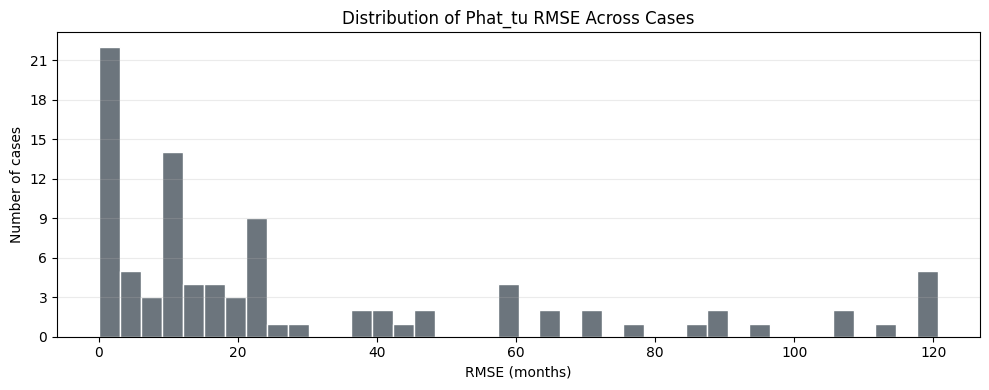

In [8]:
rmse_df = df[["doc_id", "source_file", "rmse_months", "n_defendants_scored"]].copy()
rmse_df = rmse_df.sort_values("rmse_months", ascending=True).reset_index(drop=True)

best_cases = rmse_df.head(TOP_N)
worst_cases = rmse_df.sort_values("rmse_months", ascending=False).head(TOP_N).reset_index(drop=True)

print(f"Most accurate cases by Phat_tu RMSE (lower is better): top {TOP_N}")
display(best_cases)

print(f"Least accurate cases by Phat_tu RMSE (higher is worse): top {TOP_N}")
display(worst_cases)

from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(10, 4))
bins = min(40, max(10, len(df) // 2))
ax.hist(df["rmse_months"], bins=bins, color="#6c757d", edgecolor="white")
print(bins)
ax.set_title("Distribution of Phat_tu RMSE Across Cases")
ax.set_xlabel("RMSE (months)")
ax.set_ylabel("Number of cases")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()